# Data Science Toolkit

A reusable notebook for exploring **any tabular CSV dataset**: inspection, transformation, descriptive statistics, relationships, outliers, visualization and principal component analysis (PCA).

**How to use it:** edit only the **Configuration** cell below, then run all cells (*Run All*). Everything else adapts to the dataset automatically.

## Part 1 - Setup
This first part sets up the whole toolkit: which file to read, which columns to analyse and how the results should look.

In [32]:
# Load packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from pathlib import Path

## Configuration
**This is the only cell you normally need to edit.** Every option has a sensible default (`None` / `"auto"`), so a new dataset usually works without changing anything.

In [33]:
# ============================================================
# CONFIGURATION
# ============================================================

# --- Data loading ---
DATA_DIR = "data"         # folder (relative to this notebook) that holds the dataset
DATA_FILE = None          # None = the single .csv in DATA_DIR, or a file name like "my_file.csv"
CSV_SEPARATOR = None      # None = auto-detect (",", ";", tab, ...), or e.g. ";"
HAS_HEADER = "auto"       # "auto", True or False (False -> columns are named col_1, col_2, ...)
INDEX_COL = None          # None, or the name/position of an ID column to use as row index

# --- Column selection (Part 2) ---
TARGET_COL = "auto"       # "auto" = last column if it looks like labels, a column name, or None
FEATURE_COLUMNS = None    # None = all numeric columns except the target, or a list of column names
DROP_COLUMNS = []         # columns to always exclude, e.g. ["id"]
MISSING_VALUES = "drop"   # "drop" rows, fill with "mean" or "median", or None to leave as-is

# --- Transformation (Part 3) ---
ACTIVE_TRANSFORM = "standard"  # dataset used for PCA: None, "minmax", "standard", "robust" or "log"

# --- Descriptive analysis (Part 4) ---
STATS_COLUMNS = None      # None = all feature columns, or a list of column names

# --- Relationships (Part 5) ---
VAR_X = None              # None = first feature column
VAR_Y = None              # None = second feature column

# --- Outliers (Part 6) ---
OUTLIER_COLUMNS = None    # None = all feature columns
OUTLIER_METHOD = "iqr"    # "iqr" or "zscore"
IQR_FACTOR = 1.5          # IQR method: outside [Q1 - k*IQR, Q3 + k*IQR]
ZSCORE_THRESHOLD = 3.0    # z-score method: |z| > threshold

# --- Visualization (Part 7) ---
PLOT_COLUMNS = None       # None = first 4 feature columns (scatter: exactly 2 columns [x, y])
PLOT_TYPE = "hist"        # "hist", "box", "violin", "scatter" or "line"
PLOT_SOURCE = "raw"       # "raw" or a transform: "minmax", "standard", "robust", "log"
PLOT_COLOR = "tab:blue"   # any matplotlib color
PLOT_TITLE = None         # None = automatic title
HIST_BINS = 30
COLOR_BY_TARGET = True    # color points/histograms by target class (when a target exists)

# --- Relationship maps (Part 8) ---
MAP_COLUMNS = None        # None = all feature columns
CORR_METHOD = "pearson"   # "pearson" or "spearman"
HEATMAP_CMAP = "coolwarm"

# --- PCA (Part 9) ---
N_COMPONENTS = 3          # 2 or 3

# --- Output ---
SAVE_PLOTS = False        # True = save every figure as PNG in OUTPUT_DIR
OUTPUT_DIR = "output"
FIGURE_DPI = 150

### Helper functions
Shared utilities used by the rest of the notebook. No need to edit.

In [34]:
TRANSFORMS = ("minmax", "standard", "robust", "log")


def resolve_columns(selection, default, label="columns"):
    """Return a validated list of numeric columns; None falls back to `default`."""
    cols = list(default) if selection is None else ([selection] if isinstance(selection, str) else list(selection))
    unknown = [c for c in cols if c not in df.columns]
    if unknown:
        raise KeyError(f"{label}: unknown column(s) {unknown}. Available: {list(df.columns)}")
    non_numeric = [c for c in cols if not pd.api.types.is_numeric_dtype(df[c])]
    if non_numeric:
        raise TypeError(f"{label}: non-numeric column(s) {non_numeric}")
    if not cols:
        raise ValueError(f"{label}: no columns selected")
    return cols


def save_figure(fig, name):
    """Save `fig` to OUTPUT_DIR when SAVE_PLOTS is enabled."""
    if not SAVE_PLOTS:
        return
    out_dir = Path(OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / f"{name}.png"
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"Saved: {path}")


def grid_shape(n, max_cols=3):
    n_cols = min(n, max_cols)
    return int(np.ceil(n / n_cols)), n_cols


def target_groups():
    """Yield (label, row mask) per target class, or a single group when coloring is off."""
    if COLOR_BY_TARGET and target_col is not None:
        for label in sorted(df[target_col].dropna().unique(), key=str):
            yield label, (df[target_col] == label).to_numpy()
    else:
        yield None, np.ones(len(df), dtype=bool)


def scatter_by_target(ax, *coords):
    """Scatter 2D/3D points (arrays aligned with `df`), colored by target when available."""
    for label, mask in target_groups():
        kwargs = {"label": str(label)} if label is not None else {"color": PLOT_COLOR}
        ax.scatter(*(np.asarray(c)[mask] for c in coords), alpha=0.7, s=15, **kwargs)
    if COLOR_BY_TARGET and target_col is not None:
        ax.legend(title=target_col)


def correlation_strength(r):
    a = abs(r)
    strength = ("negligible" if a < 0.1 else "weak" if a < 0.3 else "moderate" if a < 0.5
                else "strong" if a < 0.7 else "very strong")
    return f"{strength} {'positive' if r > 0 else 'negative'}" if a >= 0.1 else strength


def plot_heatmap(matrix, title, symmetric=True, vmin=None, vmax=None):
    n = len(matrix)
    size = max(5, min(0.45 * n + 2, 18))
    fig, ax = plt.subplots(figsize=(size + 1, size))
    if symmetric and vmin is None:
        vmax = np.nanmax(np.abs(matrix.to_numpy()))
        vmin = -vmax
    im = ax.imshow(matrix.to_numpy(), cmap=HEATMAP_CMAP, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(n), matrix.columns, rotation=90)
    ax.set_yticks(range(n), matrix.index)
    if n <= 12:  # annotate only when the cells are large enough to read
        for i in range(n):
            for j in range(n):
                ax.text(j, i, f"{matrix.iat[i, j]:.2g}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.grid(False)
    fig.tight_layout()
    return fig

## Reads file
Reads the dataset from the `data/` folder (`DATA_DIR`). Uses `DATA_FILE` if set; otherwise there must be exactly one `.csv` file in that folder. The separator and header row are detected automatically unless set in the configuration.

In [35]:
data_dir = Path(DATA_DIR)
if not data_dir.is_dir():
    raise FileNotFoundError(f"Data folder not found: {data_dir.resolve()}. Create it and put your CSV inside.")

if DATA_FILE:
    data_path = data_dir / DATA_FILE
    if not data_path.is_file():
        raise FileNotFoundError(f"DATA_FILE not found: {data_path.resolve()}")
else:
    csv_files = sorted(data_dir.glob("*.csv"))
    if len(csv_files) != 1:
        raise FileNotFoundError(
            f"Expected one CSV file in {data_dir.resolve()}, found: {[f.name for f in csv_files]}. "
            "Set DATA_FILE in the configuration cell."
        )
    data_path = csv_files[0]

read_kwargs = {"sep": CSV_SEPARATOR} if CSV_SEPARATOR else {"sep": None, "engine": "python"}

if HAS_HEADER == "auto":
    # A header exists when some column is text in the first row but numeric in the rows below it.
    sample = pd.read_csv(data_path, header=None, nrows=50, **read_kwargs)
    first_numeric = pd.to_numeric(sample.iloc[0], errors="coerce").notna()
    rest_numeric = sample.iloc[1:].apply(lambda c: pd.to_numeric(c, errors="coerce").notna().all())
    has_header = bool((rest_numeric & ~first_numeric).any() or not rest_numeric.any())
else:
    has_header = bool(HAS_HEADER)

print(f"Reading: {data_path} (header row: {'yes' if has_header else 'no'})")

Reading: data/breast_cancer_raw.csv (header row: no)


Loads the data from the dataset into `df_raw`. This original copy is never modified, so re-running the later cells always starts from the original data.

In [36]:
df_raw = pd.read_csv(data_path, header=0 if has_header else None, index_col=INDEX_COL, **read_kwargs)
if not has_header:
    df_raw.columns = [f"col_{i + 1}" for i in range(df_raw.shape[1])]
df_raw.columns = df_raw.columns.astype(str).str.strip()
df_raw.head()

,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,...,col_22,col_23,col_24,col_25,col_26,col_27,col_28,col_29,col_30,col_31
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Part 2 - Data inspection
This part inspects the dataset: its dimensions, the column names and data types, missing values and basic descriptive statistics. Finally, the columns used in the rest of the toolkit are selected.

### Dataset display

In [37]:
# Dimensions
rows, columns = df_raw.shape
print(f"Rows: {rows}, Columns: {columns}")

Rows: 569, Columns: 31


In [38]:
# Column names, data types and missing values
pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "non_null": df_raw.notna().sum(),
    "missing": df_raw.isna().sum(),
    "unique": df_raw.nunique(),
})

,dtype,non_null,missing,unique
col_1,float64,569,0,456
col_2,float64,569,0,479
col_3,float64,569,0,522
col_4,float64,569,0,539
col_5,float64,569,0,474
col_6,float64,569,0,537
col_7,float64,569,0,537
col_8,float64,569,0,542
col_9,float64,569,0,432
col_10,float64,569,0,499


Basic descriptive statistics: count, mean, standard deviation, minimum, Q1, Q2 (median), Q3 and maximum of each numeric column.

In [39]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
col_1,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
col_2,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
col_3,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
col_4,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
col_5,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
col_6,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
col_7,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
col_8,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
col_9,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
col_10,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### Column selection
Builds the working dataset `df` from `df_raw` using `TARGET_COL`, `FEATURE_COLUMNS`, `DROP_COLUMNS` and `MISSING_VALUES`.

In [40]:
df = df_raw.copy()  # re-running restores the original dataset
df = df.drop(columns=[c for c in DROP_COLUMNS if c in df.columns])

# Target column
if TARGET_COL == "auto":
    last = df.columns[-1]
    n_unique = df[last].nunique(dropna=True)
    target_col = last if 1 < n_unique <= 20 and n_unique < len(df) else None
elif TARGET_COL is None:
    target_col = None
else:
    if TARGET_COL not in df.columns:
        raise KeyError(f"TARGET_COL '{TARGET_COL}' not found. Available: {list(df.columns)}")
    target_col = TARGET_COL

# Feature columns
default_features = [c for c in df.select_dtypes("number").columns if c != target_col]
constant = [c for c in default_features if df[c].nunique(dropna=True) <= 1]
if constant and FEATURE_COLUMNS is None:
    print(f"Skipping constant column(s): {constant}")
    default_features = [c for c in default_features if c not in constant]
feature_cols = resolve_columns(FEATURE_COLUMNS, default_features, "FEATURE_COLUMNS")
if target_col in feature_cols:
    raise ValueError(f"The target column '{target_col}' cannot also be a feature")

# Missing values
n_missing = int(df[feature_cols].isna().sum().sum())
if MISSING_VALUES == "drop":
    df = df.dropna(subset=feature_cols)
elif MISSING_VALUES in ("mean", "median"):
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].agg(MISSING_VALUES))
elif MISSING_VALUES is not None:
    raise ValueError('MISSING_VALUES must be "drop", "mean", "median" or None')

y = df[target_col] if target_col else None

print(f"Target column: {target_col}")
if y is not None:
    print("Class counts:", y.value_counts().to_dict())
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
print(f"Missing feature values: {n_missing} (handling: {MISSING_VALUES})")
print(f"Working dataset: {df.shape[0]} rows")

Target column: col_31
Class counts: {1: 357, 0: 212}
Feature columns (30): ['col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17', 'col_18', 'col_19', 'col_20', 'col_21', 'col_22', 'col_23', 'col_24', 'col_25', 'col_26', 'col_27', 'col_28', 'col_29', 'col_30']
Missing feature values: 0 (handling: drop)
Working dataset: 569 rows


## Part 3 - Data transformation
This applies min-max normalization, standardization, robust scaling and log transformation to the feature columns. All results are kept in `transformed`; `ACTIVE_TRANSFORM` decides which one is used for PCA.

In [41]:
# Feature data that will be transformed
features = df[feature_cols]
transformed = {}

In [42]:
# Min-max normalization: rescales each column to [0, 1]
col_range = features.max() - features.min()
transformed["minmax"] = (features - features.min()) / col_range.replace(0, 1)
transformed["minmax"].head()

,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,...,col_21,col_22,col_23,col_24,col_25,col_26,col_27,col_28,col_29,col_30
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595


In [43]:
# Standardization (z-score): mean 0, standard deviation 1
transformed["standard"] = (features - features.mean()) / features.std(ddof=0).replace(0, 1)
transformed["standard"].head()

,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,...,col_21,col_22,col_23,col_24,col_25,col_26,col_27,col_28,col_29,col_30
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [44]:
# Robust scaling: centers on the median and scales by the IQR (less sensitive to outliers)
iqr = features.quantile(0.75) - features.quantile(0.25)
transformed["robust"] = (features - features.median()) / iqr.replace(0, 1)
transformed["robust"].head()

,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,...,col_21,col_22,col_23,col_24,col_25,col_26,col_27,col_28,col_29,col_30
0,1.132353,-1.502664,1.263740,1.241446,1.190174,2.824832,2.358711,2.115850,1.855030,2.039192,...,1.801038,-0.935185,2.105595,2.343063,1.051020,2.364252,1.807750,1.715248,2.635556,1.884578
1,1.764706,-0.190053,1.612859,2.138245,-0.587956,-0.213653,0.250742,0.682995,0.059172,-0.578385,...,1.733564,-0.231481,1.480746,2.232284,-0.255102,-0.131839,0.055514,0.892194,-0.106667,0.435500
2,1.549020,0.428064,1.512617,1.798841,0.725304,1.027337,1.343287,1.758242,0.819527,-0.184086,...,1.487889,0.013889,1.328167,1.797960,0.445578,1.107869,0.833458,1.483052,1.171852,0.365664
3,-0.477941,0.273535,-0.299343,-0.455298,2.463286,2.921045,1.778327,1.335444,2.381657,4.263658,...,-0.010381,0.126157,0.029305,-0.208897,2.670068,3.410109,1.714605,1.633358,5.653333,4.508244
4,1.696078,-0.799290,1.688904,2.058223,0.234020,0.613470,1.349219,1.318681,0.050296,-0.321853,...,1.309689,-1.011574,1.320901,1.562335,0.207483,-0.035956,0.645678,0.648595,-0.678519,-0.158099


In [45]:
# Log transformation: log(1 + x); columns with negative values are shifted to start at 0 first
shift = (-features.min()).clip(lower=0)
transformed["log"] = np.log1p(features + shift)
if (shift > 0).any():
    print("Shifted before log:", list(shift[shift > 0].index))
transformed["log"].head()

,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,...,col_21,col_22,col_23,col_24,col_25,col_26,col_27,col_28,col_29,col_30
0,2.943913,2.431857,4.818667,6.909753,0.111899,0.244983,0.262441,0.137237,0.216642,0.075766,...,3.272606,2.908539,5.223594,7.610853,0.150315,0.510185,0.537604,0.235388,0.378505,0.112346
1,3.071303,2.932260,4.897093,7.190676,0.081340,0.075701,0.083330,0.067818,0.166531,0.055122,...,3.257712,3.194993,5.073923,7.579168,0.116716,0.171092,0.216401,0.170586,0.242946,0.085278
2,3.029650,3.102342,4.875197,7.093405,0.104000,0.148334,0.180153,0.120357,0.188055,0.058259,...,3.201526,3.278276,5.033701,7.444249,0.134880,0.353821,0.371839,0.217528,0.308440,0.083955
3,2.519308,3.062456,4.364117,5.958683,0.133219,0.249902,0.216240,0.100026,0.230874,0.092980,...,2.766948,3.314186,4.603869,6.343353,0.190455,0.623958,0.522893,0.229126,0.509104,0.159565
4,3.058237,2.730464,4.913390,7.168580,0.095583,0.124692,0.180653,0.099212,0.166277,0.057165,...,3.158701,2.871868,5.031744,7.362645,0.128745,0.186480,0.336472,0.150573,0.212204,0.073975


In [46]:
# Active dataset used downstream (PCA)
if ACTIVE_TRANSFORM is None:
    df_active = features
elif ACTIVE_TRANSFORM in transformed:
    df_active = transformed[ACTIVE_TRANSFORM]
else:
    raise ValueError(f"ACTIVE_TRANSFORM must be None or one of {TRANSFORMS}")
print(f"Active dataset: {ACTIVE_TRANSFORM or 'raw'} {df_active.shape}")

Active dataset: standard (569, 30)


## Part 4 - Descriptive analysis
Statistics for the selected variables (`STATS_COLUMNS`), in their original units: central tendency, spread, range and quartiles.

In [47]:
stats_cols = resolve_columns(STATS_COLUMNS, feature_cols, "STATS_COLUMNS")
data = df[stats_cols]

stats = pd.DataFrame({
    # Central tendency
    "mean": data.mean(),
    "median": data.median(),
    "mode": data.mode().iloc[0],
    # Spread
    "std": data.std(),
    "variance": data.var(),
    # Range
    "min": data.min(),
    "max": data.max(),
    "range": data.max() - data.min(),
    # Quartiles
    "Q1": data.quantile(0.25),
    "Q2": data.quantile(0.50),
    "Q3": data.quantile(0.75),
    "IQR": data.quantile(0.75) - data.quantile(0.25),
})
stats

,mean,median,mode,std,variance,min,max,range,Q1,Q2,Q3,IQR
col_1,14.127292,13.370000,12.340000,3.524049,12.418920,6.981000,28.11000,21.129000,11.700000,13.370000,15.780000,4.080000
col_2,19.289649,18.840000,14.930000,4.301036,18.498909,9.710000,39.28000,29.570000,16.170000,18.840000,21.800000,5.630000
col_3,91.969033,86.240000,82.610000,24.298981,590.440480,43.790000,188.50000,144.710000,75.170000,86.240000,104.100000,28.930000
col_4,654.889104,551.100000,512.200000,351.914129,123843.554318,143.500000,2501.00000,2357.500000,420.300000,551.100000,782.700000,362.400000
col_5,0.096360,0.095870,0.100700,0.014064,0.000198,0.052630,0.16340,0.110770,0.086370,0.095870,0.105300,0.018930
col_6,0.104341,0.092630,0.114700,0.052813,0.002789,0.019380,0.34540,0.326020,0.064920,0.092630,0.130400,0.065480
col_7,0.088799,0.061540,0.000000,0.079720,0.006355,0.000000,0.42680,0.426800,0.029560,0.061540,0.130700,0.101140
col_8,0.048919,0.033500,0.000000,0.038803,0.001506,0.000000,0.20120,0.201200,0.020310,0.033500,0.074000,0.053690
col_9,0.181162,0.179200,0.160100,0.027414,0.000752,0.106000,0.30400,0.198000,0.161900,0.179200,0.195700,0.033800
col_10,0.062798,0.061540,0.056670,0.007060,0.000050,0.049960,0.09744,0.047480,0.057700,0.061540,0.066120,0.008420


## Part 5 - Relationships
Are your 2 variables in love with each other? Find out!

Set `VAR_X` and `VAR_Y` in the configuration to choose the pair. Here you can calculate the Pearson correlation, Spearman correlation and covariance.

In [48]:
if len(feature_cols) < 2 and (VAR_X is None or VAR_Y is None):
    raise ValueError("At least two feature columns are needed; set VAR_X and VAR_Y")
x_col, y_col = resolve_columns([VAR_X or feature_cols[0], VAR_Y or feature_cols[1]], [], "VAR_X/VAR_Y")
pair = df[[x_col, y_col]].dropna()
print(f"Variables: {x_col} vs {y_col} ({len(pair)} rows)")

Variables: col_1 vs col_2 (569 rows)


In [49]:
# Pearson correlation: strength of the linear relationship
pearson = pair[x_col].corr(pair[y_col], method="pearson")
print(f"Pearson r = {pearson:.4f} ({correlation_strength(pearson)})")

Pearson r = 0.3238 (moderate positive)


In [50]:
# Spearman correlation: strength of the monotonic (rank-based) relationship
spearman = pair[x_col].corr(pair[y_col], method="spearman")
print(f"Spearman rho = {spearman:.4f} ({correlation_strength(spearman)})")

Spearman rho = 0.3410 (moderate positive)


In [51]:
# Covariance: direction of the joint variation (scale dependent)
covariance = pair[x_col].cov(pair[y_col])
print(f"Covariance = {covariance:.4f}")

Covariance = 4.9076


## Part 6 - Outlier analysis
Identify and inspect potential outliers with the IQR rule or z-scores (`OUTLIER_METHOD`).

In [52]:
outlier_cols = resolve_columns(OUTLIER_COLUMNS, feature_cols, "OUTLIER_COLUMNS")
data = df[outlier_cols]

# Detect outliers
if OUTLIER_METHOD == "iqr":
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    lower, upper = q1 - IQR_FACTOR * (q3 - q1), q3 + IQR_FACTOR * (q3 - q1)
elif OUTLIER_METHOD == "zscore":
    lower = data.mean() - ZSCORE_THRESHOLD * data.std()
    upper = data.mean() + ZSCORE_THRESHOLD * data.std()
else:
    raise ValueError('OUTLIER_METHOD must be "iqr" or "zscore"')
outlier_mask = data.lt(lower) | data.gt(upper)

# Results per column
outlier_summary = pd.DataFrame({
    "lower_bound": lower,
    "upper_bound": upper,
    "n_outliers": outlier_mask.sum(),
    "pct_outliers": (outlier_mask.mean() * 100).round(2),
}).sort_values("n_outliers", ascending=False)
outlier_rows = df[outlier_mask.any(axis=1)]
print(f"Method: {OUTLIER_METHOD} | rows with at least one outlier: {len(outlier_rows)} of {len(df)}")
outlier_summary

Method: iqr | rows with at least one outlier: 171 of 569


,lower_bound,upper_bound,n_outliers,pct_outliers
col_14,-23.160000,86.200000,65,11.42
col_11,-0.137350,0.848650,38,6.68
col_13,-1.020500,5.983500,38,6.68
col_24,-337.750000,1937.050000,35,6.15
col_15,0.000703,0.012612,30,5.27
col_20,-0.001217,0.008023,28,4.92
col_16,-0.015975,0.061505,28,4.92
col_19,0.002680,0.035960,27,4.75
col_4,-123.300000,1326.300000,25,4.39
col_30,0.040530,0.123010,24,4.22


In [53]:
# Rows containing outliers (first 10)
outlier_rows.head(10)

,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,...,col_22,col_23,col_24,col_25,col_26,col_27,col_28,col_29,col_30,col_31
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.1859,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.2273,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0
12,19.17,24.80,132.40,1123.0,0.09740,0.24580,0.2065,0.11180,0.2397,0.07800,...,29.94,151.70,1332.0,0.1037,0.3903,0.3639,0.1767,0.3176,0.10230,0
14,13.73,22.61,93.60,578.3,0.11310,0.22930,0.2128,0.08025,0.2069,0.07682,...,32.01,108.80,697.7,0.1651,0.7725,0.6943,0.2208,0.3596,0.14310,0


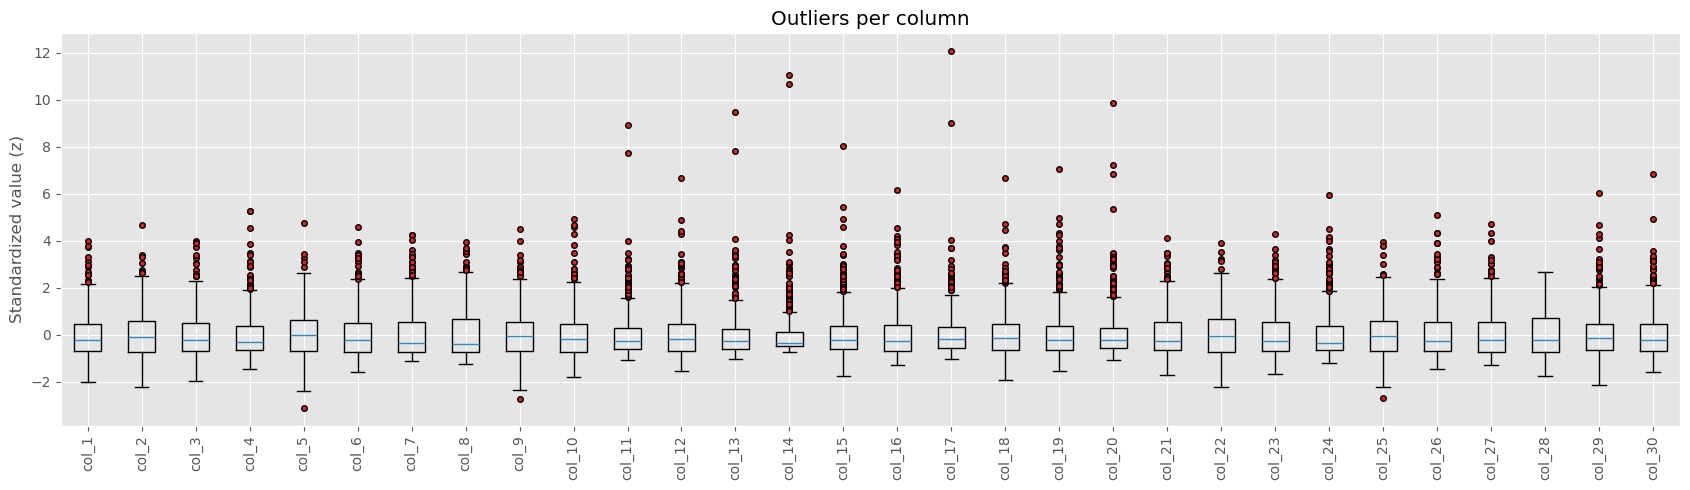

In [54]:
# Visualize outliers: boxplots on standardized values so all columns share one scale
z = (data - data.mean()) / data.std().replace(0, 1)
fig, ax = plt.subplots(figsize=(max(6, 0.5 * len(outlier_cols) + 2), 5))
ax.boxplot(z.to_numpy(), whis=IQR_FACTOR, flierprops={"markerfacecolor": "tab:red", "markersize": 4})
ax.set_xticks(range(1, len(outlier_cols) + 1), outlier_cols, rotation=90)
ax.set_ylabel("Standardized value (z)")
ax.set_title("Outliers per column")
fig.tight_layout()
save_figure(fig, "outliers_boxplot")
plt.show()

## Part 7 - Visualization
Visualize the dataset with histograms, boxplots, violin plots, scatter plots or line plots. Choose the columns, plot type, data source, color and title in the configuration (`PLOT_*`), and set `SAVE_PLOTS = True` to save the figure.

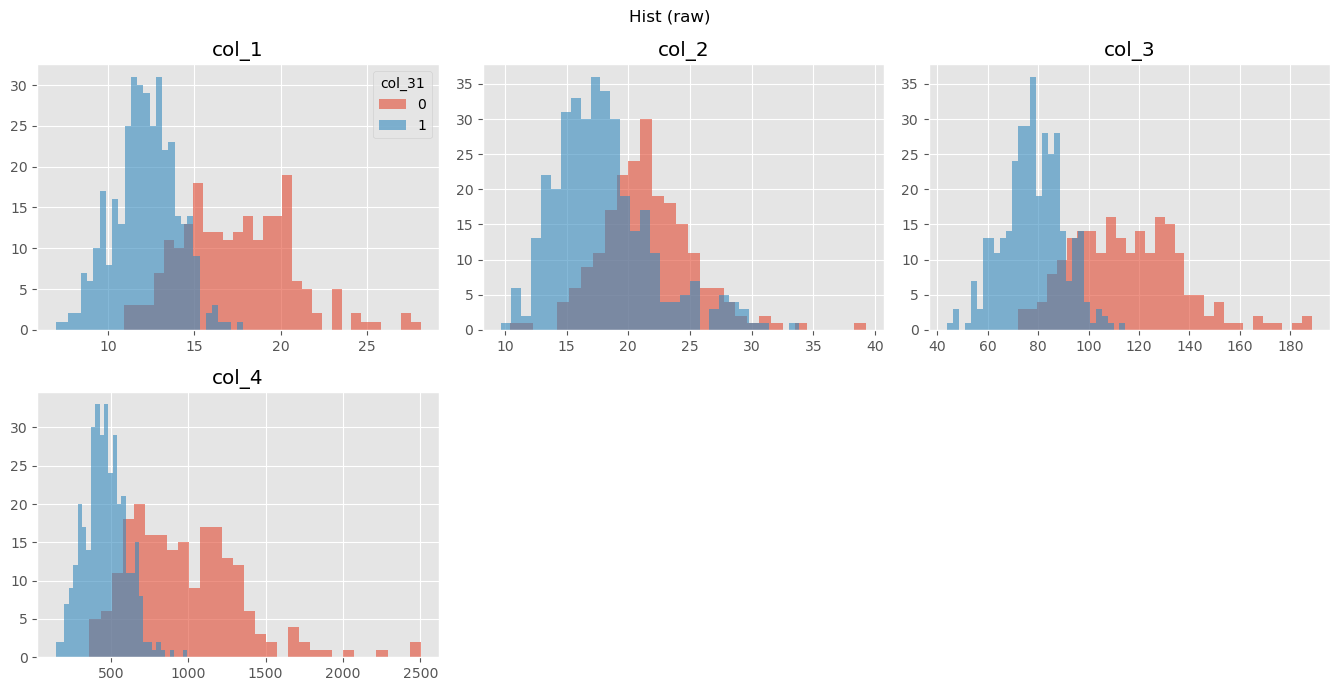

In [55]:
plot_cols = resolve_columns(PLOT_COLUMNS, feature_cols[:4], "PLOT_COLUMNS")
if PLOT_SOURCE == "raw":
    plot_data = df[plot_cols]
elif PLOT_SOURCE in transformed:
    plot_data = transformed[PLOT_SOURCE][plot_cols]
else:
    raise ValueError(f'PLOT_SOURCE must be "raw" or one of {TRANSFORMS}')

title = PLOT_TITLE or f"{PLOT_TYPE.capitalize()} ({PLOT_SOURCE})"
plt.style.use("ggplot")

if PLOT_TYPE == "hist":
    n_rows, n_cols = grid_shape(len(plot_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.5 * n_rows), squeeze=False)
    for ax, col in zip(axes.flat, plot_cols):
        for label, mask in target_groups():
            ax.hist(plot_data[col][mask].dropna(), bins=HIST_BINS, alpha=0.6,
                    color=PLOT_COLOR if label is None else None,
                    label=None if label is None else str(label))
        ax.set_title(col)
    for ax in axes.flat[len(plot_cols):]:
        ax.set_visible(False)
    if COLOR_BY_TARGET and target_col is not None:
        axes.flat[0].legend(title=target_col)

elif PLOT_TYPE in ("box", "violin"):
    fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(plot_cols) + 2), 5))
    values = [plot_data[c].dropna().to_numpy() for c in plot_cols]
    if PLOT_TYPE == "box":
        ax.boxplot(values, patch_artist=True, boxprops={"facecolor": PLOT_COLOR, "alpha": 0.6})
    else:
        parts = ax.violinplot(values, showmedians=True)
        for body in parts["bodies"]:
            body.set_facecolor(PLOT_COLOR)
    ax.set_xticks(range(1, len(plot_cols) + 1), plot_cols, rotation=45, ha="right")

elif PLOT_TYPE == "scatter":
    if len(plot_cols) != 2:
        raise ValueError("A scatter plot needs exactly 2 columns in PLOT_COLUMNS, e.g. ['a', 'b']")
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter_by_target(ax, plot_data[plot_cols[0]], plot_data[plot_cols[1]])
    ax.set_xlabel(plot_cols[0])
    ax.set_ylabel(plot_cols[1])

elif PLOT_TYPE == "line":
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_data.plot(ax=ax, color=PLOT_COLOR if len(plot_cols) == 1 else None)
    ax.set_xlabel(df.index.name or "index")

else:
    raise ValueError('PLOT_TYPE must be "hist", "box", "violin", "scatter" or "line"')

fig.suptitle(title)
fig.tight_layout()
save_figure(fig, f"plot_{PLOT_TYPE}_{PLOT_SOURCE}")
plt.show()

## Part 8 - Relationship maps
Visualize relationships across multiple numerical variables (`MAP_COLUMNS`). Values are annotated when there are 12 columns or fewer.

In [56]:
map_cols = resolve_columns(MAP_COLUMNS, feature_cols, "MAP_COLUMNS")
if len(map_cols) < 2:
    raise ValueError("MAP_COLUMNS needs at least 2 columns")
print(f"Columns in relationship maps ({len(map_cols)}): {map_cols}")

Columns in relationship maps (30): ['col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17', 'col_18', 'col_19', 'col_20', 'col_21', 'col_22', 'col_23', 'col_24', 'col_25', 'col_26', 'col_27', 'col_28', 'col_29', 'col_30']


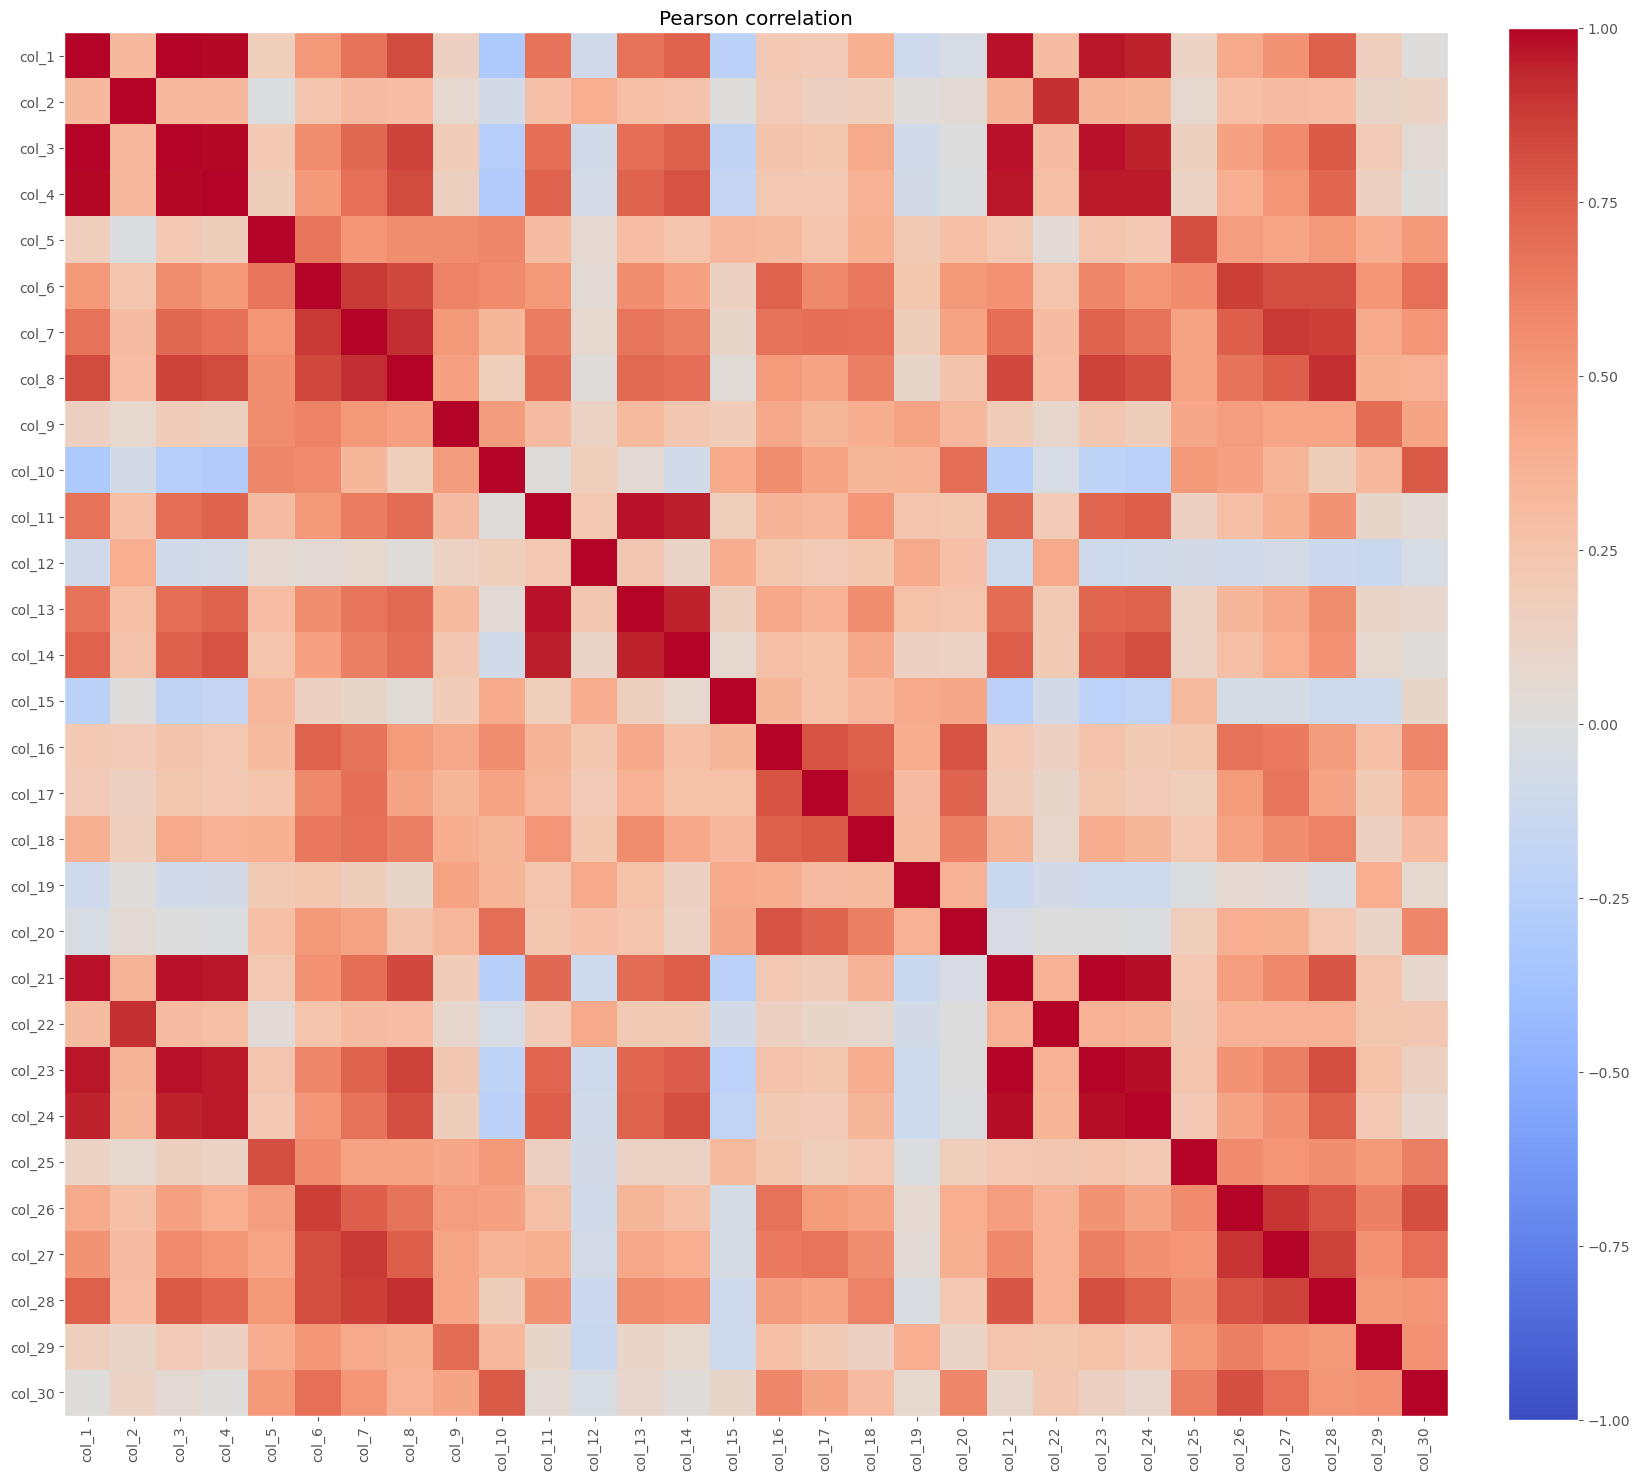

In [ ]:
# Correlation heatmap
corr_matrix = df[map_cols].corr(method=CORR_METHOD)
fig = plot_heatmap(corr_matrix, f"{CORR_METHOD.capitalize()} correlation", vmin=-1, vmax=1)
save_figure(fig, f"heatmap_correlation_{CORR_METHOD}")
plt.show()

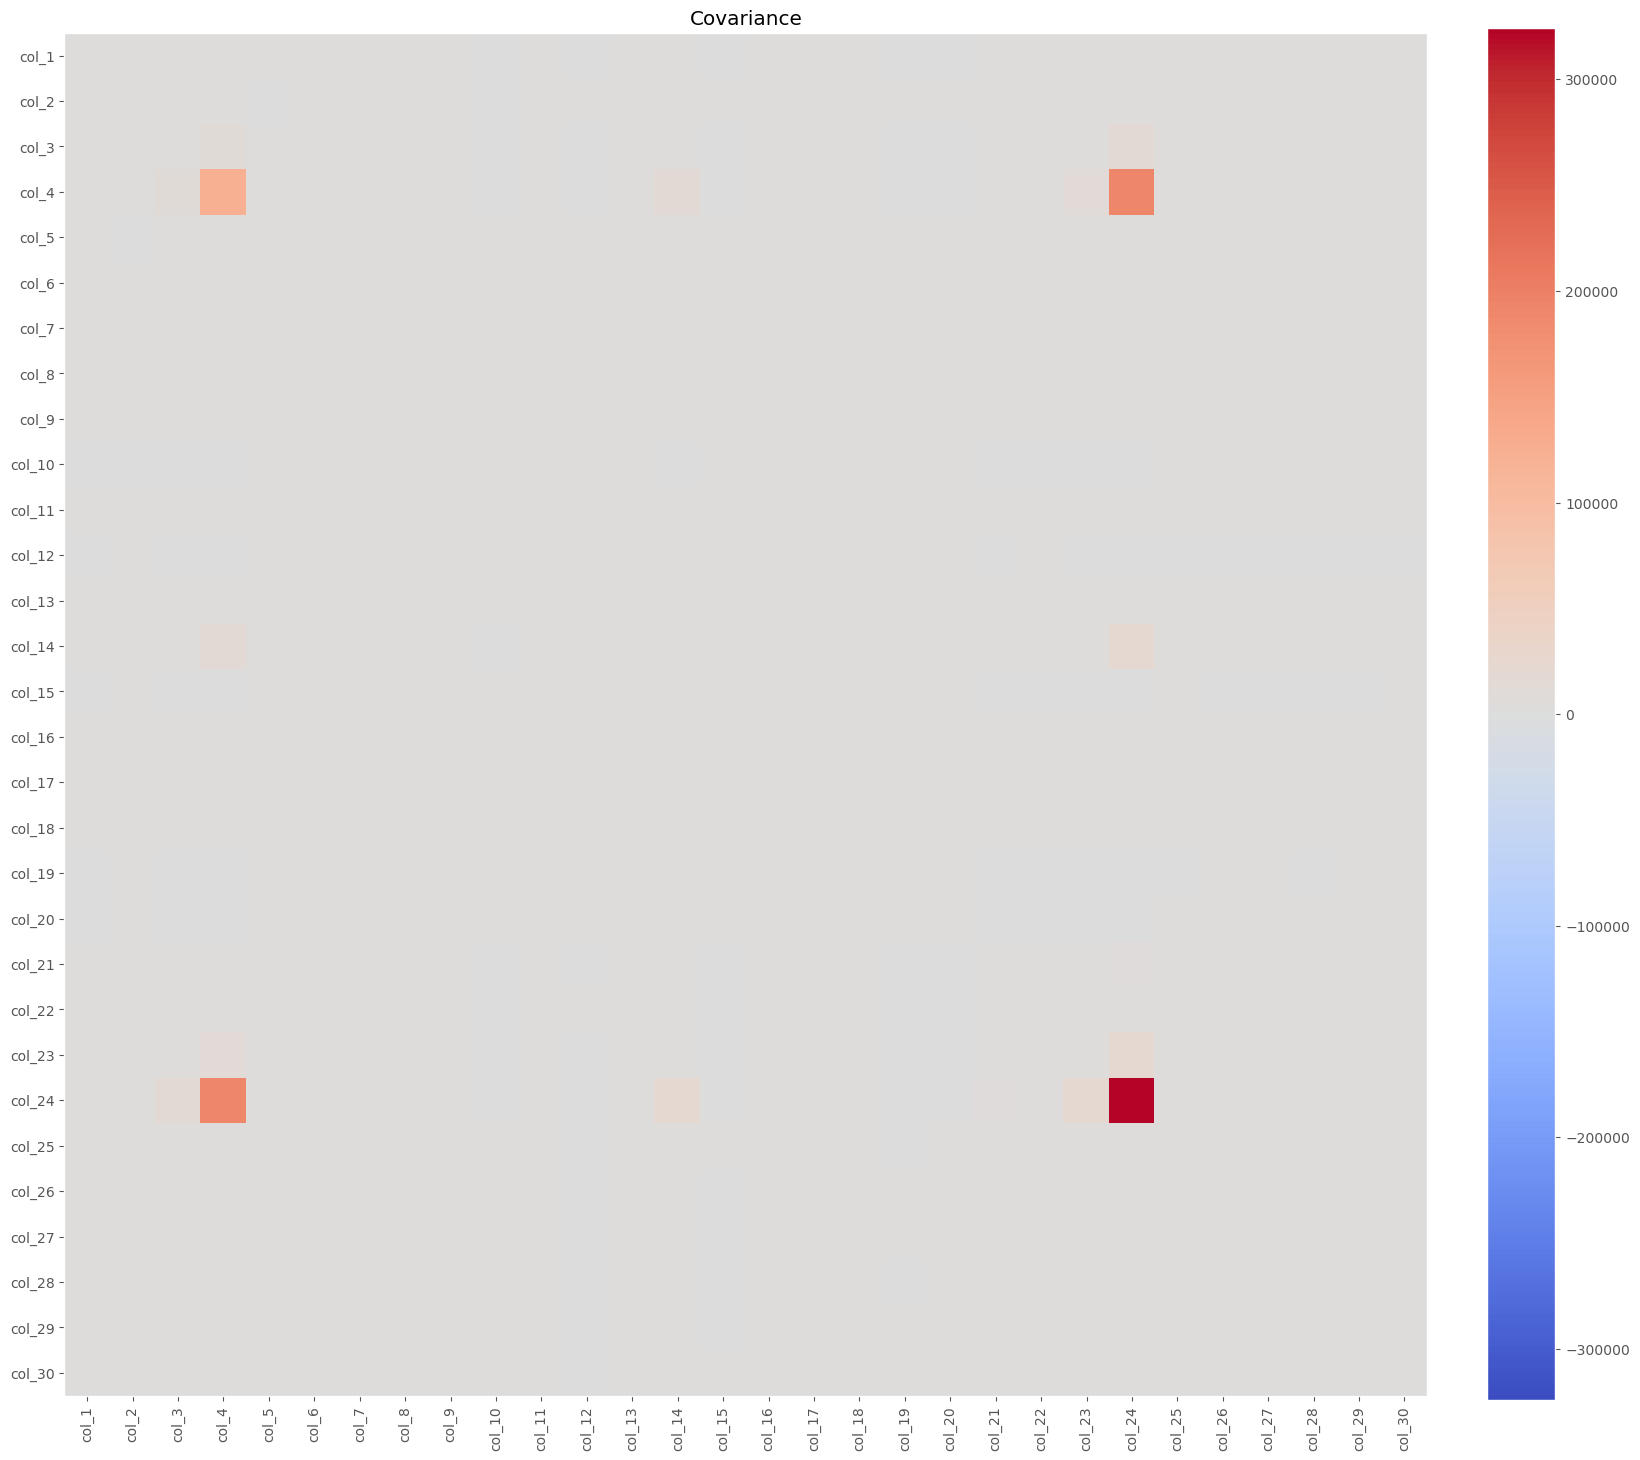

In [58]:
# Covariance heatmap (scale dependent: columns with large values dominate)
cov_matrix = df[map_cols].cov()
fig = plot_heatmap(cov_matrix, "Covariance")
save_figure(fig, "heatmap_covariance")
plt.show()

## Part 9 - Principal Component Analysis
When you have a very wide dataset, you can reduce its dimensionality using principal component analysis (PCA). PCA relies on the concepts of linear transformations and singular value decomposition (SVD) in linear algebra.
Luckily, scikit-learn provides a package that we can use to perform PCA instead of worrying about the linear algebra. You can find the documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).

PCA runs on the active dataset from Part 3 (`ACTIVE_TRANSFORM`). Standardizing first is recommended, otherwise columns with large values dominate the components.

In [59]:
if N_COMPONENTS not in (2, 3):
    raise ValueError("N_COMPONENTS must be 2 or 3.")
if N_COMPONENTS > len(feature_cols):
    raise ValueError(f"N_COMPONENTS ({N_COMPONENTS}) cannot exceed the number of features ({len(feature_cols)})")

X = df_active[feature_cols].to_numpy()
if np.isnan(X).any():
    raise ValueError("PCA cannot handle missing values; set MISSING_VALUES to 'drop', 'mean' or 'median'")

# Reduce the selected numeric features to N_COMPONENTS coordinates per row.
pca = PCA(n_components=N_COMPONENTS)
principal_comps = pca.fit_transform(X)

pc_names = [f"pc{i + 1}" for i in range(N_COMPONENTS)]
principal_df = pd.DataFrame(principal_comps, columns=pc_names, index=df.index)

# Keep labels only when the dataset provides them.
if y is not None:
    principal_df["target"] = y

for name, ratio in zip(pc_names, pca.explained_variance_ratio_):
    print(f"{name}: {ratio:.2%} of variance explained")
print(f"Total: {pca.explained_variance_ratio_.sum():.2%}")

pc1: 44.27% of variance explained
pc2: 18.97% of variance explained
pc3: 9.39% of variance explained
Total: 72.64%


In [60]:
principal_df.head()

,pc1,pc2,pc3,target
0,9.192837,1.948583,-1.123166,0
1,2.387802,-3.768172,-0.529293,0
2,5.733896,-1.075174,-0.551748,0
3,7.122953,10.275589,-3.232790,0
4,3.935302,-1.948072,1.389767,0


In [61]:
# Loadings: how much each original feature contributes to each component
loadings = pd.DataFrame(pca.components_.T, index=feature_cols, columns=pc_names)
loadings.reindex(loadings["pc1"].abs().sort_values(ascending=False).index)

,pc1,pc2,pc3
col_8,0.260854,-0.034768,-0.025564
col_7,0.258400,0.060165,0.002734
col_28,0.250886,-0.008257,-0.170344
col_6,0.239285,0.151892,-0.074092
col_23,0.236640,-0.199878,-0.048547
col_27,0.228768,0.097964,-0.173057
col_21,0.227997,-0.219866,-0.047507
col_3,0.227537,-0.215181,-0.009314
col_24,0.224871,-0.219352,-0.011902
col_4,0.220995,-0.231077,0.028700


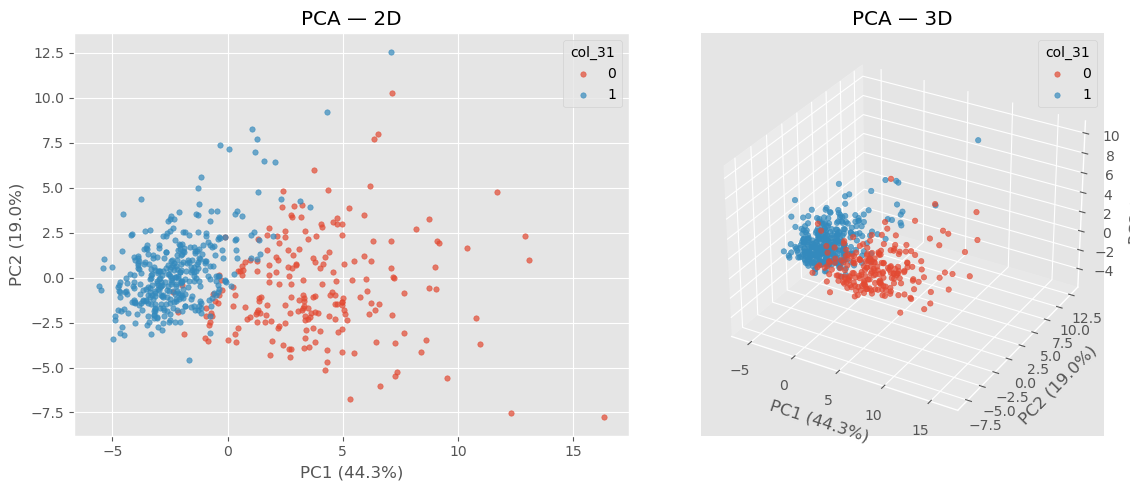

In [62]:
plt.style.use("ggplot")
var = pca.explained_variance_ratio_

if N_COMPONENTS == 3:
    fig = plt.figure(figsize=(12, 5))
    ax2d = fig.add_subplot(1, 2, 1)
    ax3d = fig.add_subplot(1, 2, 2, projection="3d")
    scatter_by_target(ax3d, principal_df["pc1"], principal_df["pc2"], principal_df["pc3"])
    ax3d.set_xlabel(f"PC1 ({var[0]:.1%})")
    ax3d.set_ylabel(f"PC2 ({var[1]:.1%})")
    ax3d.set_zlabel(f"PC3 ({var[2]:.1%})")  # pyright: ignore[reportAttributeAccessIssue]
    ax3d.set_title("PCA — 3D")
else:
    fig, ax2d = plt.subplots(figsize=(6, 5))

scatter_by_target(ax2d, principal_df["pc1"], principal_df["pc2"])
ax2d.set_xlabel(f"PC1 ({var[0]:.1%})")
ax2d.set_ylabel(f"PC2 ({var[1]:.1%})")
ax2d.set_title("PCA — 2D")

fig.tight_layout()
save_figure(fig, f"pca_{N_COMPONENTS}d")
plt.show()